# TL1: Entorno de Trabajo — Aprendizaje Automático (APA)
**Asignatura:** Aprendizaje Automático (APA) — Grado en Inteligencia Artificial (UPV)[cite: 1]
**Autor del material docente:** Alfons Juan Ciscar[cite: 1]

---

## 1. Introducción y Configuración del Entorno Virtual

Instrucciones de configuración del entorno virtual para la asignatura[cite: 2]:
```bash
git clone git@github.com:AlfonsJ/2027_02_28_APA2627.git
cd 2027_02_28_APA2627
uv venv-seed-managed-python
source .venv/bin/activate
pip install numpy matplotlib pandas scipy scikit-learn kagglehub datasets torch torchvision torchaudio
pip install ipywidgets ipykernel
python -m ipykernel install --user --name APA2627
deactivate
```

## 2. NumPy: Cálculo de Matriz de Covarianzas Empírica y Broadcasting

**Ejercicio:** Traduce a NumPy el siguiente pseudo-script[cite: 3]:

````
import numpy as np
X = matriz [-1, 1; 0, 2; 2, 0; 3, 3]
N = número de filas de X
mean = media de los datos
X_tilde = X - media
Sigma = matriz de covarianzas empírica calculada a partir de X_tilde
````

- Define la matriz $X = \begin{pmatrix} -1 & -1 \\ 0 & 2 \\ 2 & 0 \\ 3 & 3 \end{pmatrix}$[cite: 3, 4].
- $N$: número de filas de $X$[cite: 3].
- `mean`: media de los datos por columnas[cite: 3].
- `X_tilde`: datos centrados ($X - \text{mean}$) haciendo uso de *broadcasting*[cite: 3, 4].
- `Sigma`: matriz de covarianzas empírica calculada como $\frac{1}{N} \tilde{X}^T \tilde{X}$[cite: 3, 4].

In [ ]:
import numpy as np

X = np.array([
    [-1,  -1],
    [0, 2],
    [2, 0],
    [3, 3]
])


N = len(X)
C = X.shape[0]
N, C



array([1., 1.])

In [10]:
X_mean = X.mean(axis=0)
X_mean

array([1., 1.])

In [9]:
X_tilde = X - X_mean
print(f'Broadcasting {X.shape} - {X_mean.shape} -> {X_tilde.shape}')
X_tilde

Broadcasting (4, 2) - (2,) -> (4, 2)


array([[-2., -2.],
       [-1.,  1.],
       [ 1., -1.],
       [ 2.,  2.]])

In [ ]:
Sigma = (1 / N) * X_tilde.T @ X_tilde   #Manualmente se calcula la matriz
mat_cov = np.cov(X, rowvar=False, bias=True) #Metodo para hacerlo con el numpy. bias es la normalizacion
print(Sigma, mat_cov, sep='\n\n')

[[2.5 1.5]
 [1.5 2.5]]

[[2.5 1.5]
 [1.5 2.5]]


## 3. SciPy: Muestreo de Distribuciones de Probabilidad y Evaluación de PDF[cite: 5]

**Ejercicio:** Traduce a SciPy las siguientes operaciones muestrales[cite: 5]:
1. Array 1D con 10 muestras de $\text{Bernoulli}(p=0.25)$[cite: 5].
2. Array 2D con 3 muestras de una categórica (multinomial $n=1$) para 3 clases con $p = (0.3, 0.2, 0.5)$[cite: 5].
3. Array 1D con 5 muestras de $\mathcal{N}(0, 1)$[cite: 5].
4. Rejilla 1D de 5 puntos en $[-1, 1]$ y evaluación de la PDF de $\mathcal{N}(0, 1)$ en dicha rejilla[cite: 5].
5. Rejilla 2D de $3^2$ puntos en $[-1, 1]^2$ y evaluación de la PDF de una normal 2D estándar $\mathcal{N}(\mathbf{0}, \mathbf{I})$[cite: 5].

In [1]:
from scipy import stats

# Bernuli 
Y_bernuli = stats.bernoulli(0.25).rvs(10)   #rvs Random Variantes (muestras aleatorias) rvs(3) 10 muestras se generan
Y_bernuli

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [ ]:
# Categorica (Multinomial)
Y_categorica = stats.multinomial(1, [0.3, 0.2, 0.5]).rvs(3)  # el 1 indica que en cada muestra solo se realiza un único experimento
Y_categorica

array([[0, 0, 1],
       [1, 0, 0],
       [0, 0, 1]], dtype=int32)

In [ ]:
# Normal

Y_norm = stats.norm(0, 1).rvs(5)  # normal con media = 0 y desv tip = 1
Y_norm

array([-0.02253889,  0.01342226,  0.93594489,  0.42062266,  0.41161964])

In [42]:
# Rejilla 1D y Función de Densidad de Probabilidad (PDF)
Y = np.linspace(-1, 1, 5); pdf = stats.norm(0, 1).pdf(Y); print(Y, pdf)
Y, pdf

[-1.  -0.5  0.   0.5  1. ] [0.24197072 0.35206533 0.39894228 0.35206533 0.24197072]


(array([-1. , -0.5,  0. ,  0.5,  1. ]),
 array([0.24197072, 0.35206533, 0.39894228, 0.35206533, 0.24197072]))

In [43]:
# Muestreo 2D: Normal Multivariada
m = np.zeros(2)
S = np.eye(2)
Y = stats.multivariate_normal(m, S).rvs(3)
Y

array([[-0.07132392, -0.04543758],
       [ 1.04088597, -0.09403473],
       [-0.42084395, -0.55198856]])

In [44]:
# Rejilla 2D en [-1, 1]^2 y Evaluación de PDF 2D
Y = np.linspace(-1, 1, 3) # Genera los $3$ puntos [-1, 0, 1]
Y1, Y2 = np.meshgrid(Y, Y) #  Crea las matrices de coordenadas bidimensionales para formar una cuadrícula de 3 * 3 = 9 puntos.
aplanado1 = np.ravel(Y1) # Aplana las matrices 2D a vectores 1D de 9 elementos. 
aplanado2 = np.ravel(Y2)
Y = np.c_[aplanado1, aplanado2] # Concatena ambos vectores a lo largo de las columnas para formar la matriz de 9 * 2 con las coordenadas (x1, x2) de los 9 puntos de la rejilla. 
pdf = stats.multivariate_normal(m, S).pdf(Y) # Evalúa la densidad de probabilidad bidimensional en cada uno de los 9 puntos

print(Y, '\n', pdf)

[[-1. -1.]
 [ 0. -1.]
 [ 1. -1.]
 [-1.  0.]
 [ 0.  0.]
 [ 1.  0.]
 [-1.  1.]
 [ 0.  1.]
 [ 1.  1.]] 
 [0.05854983 0.09653235 0.05854983 0.09653235 0.15915494 0.09653235
 0.05854983 0.09653235 0.05854983]


## 4. Matplotlib: Formas Cuadráticas y Campos de Vectores[cite: 7]

**Ejercicio:** Estudia el código y observa el comportamiento de la función cuadrática $y = a_1 x_1^2 + a_2 x_2^2$ evaluando combinaciones de $a \in \{-1, 1\}^2$[cite: 7].

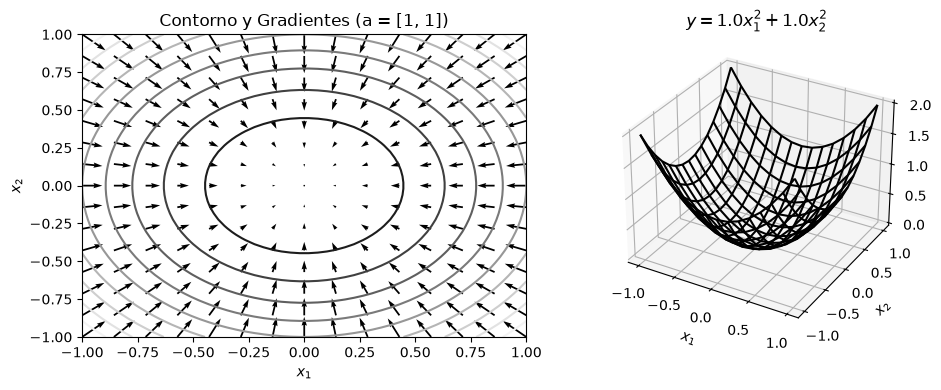

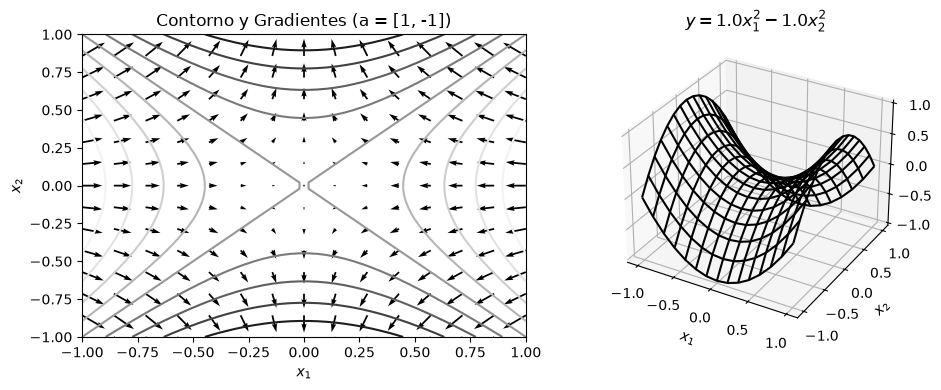

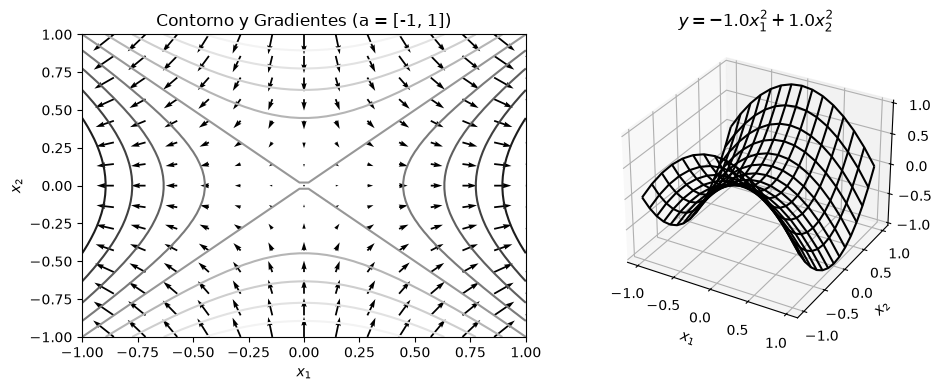

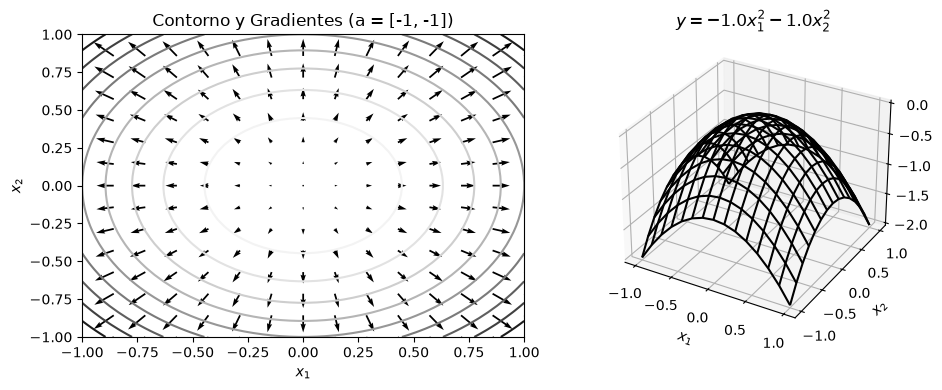

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir las 4 combinaciones posibles de 'a' en {-1, 1}^2
# [1, 1]   -> Paraboloide elíptico (cuenco hacia arriba)
# [1, -1]  -> Silla de montar
# [-1, 1]  -> Silla de montar invertida
# [-1, -1] -> Paraboloide invertido (cuenco hacia abajo)
valores_a = [[1, 1], [1, -1], [-1, 1], [-1, -1]]  

# 2. Rejilla densa (50x50 = 2500 puntos) para obtener curvas de nivel suaves
R = np.linspace(-1, 1, 50)  # 50 puntos equiespaciados en [-1, 1
X1, X2 = np.meshgrid(R, R)  # Matrices 2D con las coordenadas de la mall
X = np.c_[np.ravel(X1), np.ravel(X2)]  # Aplanar y concatenar para crear una matriz de (2500, 2

# 3. Rejilla gruesa (15x15 = 225 puntos) para representar vectores y wireframe
r = np.linspace(-1, 1, 15)  # Menos puntos para evitar que se amontonen las flecha
x1, x2 = np.meshgrid(r, r)  # Malla 2D de 15x1
x = np.c_[np.ravel(x1), np.ravel(x2)]  # Matriz de (225, 2) con coordenadas gruesa

# 4. Bucle principal: generar los gráficos para cada valor de 'a'
for a_val in valores_a:
  a = np.array(a_val)  # Convertir la lista a un array de NumP

  # Calcular la función cuadrática y = a1*x1^2 + a2*x2^2 en la rejilla densa
  # np.square(X) eleva al cuadrado, @ a aplica el producto escalar y reshape vuelve a (50, 50)
  Y = (np.square(X) @ a).reshape(X1.shape)  

  # Crear lienzo para la figura con tamaño de 10x4 pulgadas
  fig = plt.figure(figsize=(10, 4))  

  # --- SUBPLOT 1: Contornos 2D y vectores de anti-gradiente ---
  ax1 = plt.subplot(121)  # Panel izquierdo en una rejilla de 1 fila x 2 columna
  ax1.contour(X1, X2, Y, 10, cmap='Greys_r')  # Dibuja 10 isolíneas de la función 

  # Calcular el anti-gradiente: -grad(y) = -[2*a1*x1, 2*a2*x2]
  neg_grad = -x @ np.diag(2 * a)  # Direcciones de máximo descenso (descenso del gradiente

  # Dibuja el campo de vectores (flechas) sobre la rejilla gruesa
  ax1.quiver(
      x[:, 0],
      x[:, 1],
      neg_grad[:, 0],
      neg_grad[:, 1],
      color='black',
      angles='xy',
  )  
  ax1.set_title(f'Contorno y Gradientes (a = [{a[0]}, {a[1]}])')  # Título del pane
  ax1.set_xlabel('$x_1$')  # Etiqueta del eje X en formato LaTe
  ax1.set_ylabel('$x_2$')  # Etiqueta del eje Y en formato LaTe

  # --- SUBPLOT 2: Superficie 3D Wireframe ---
  ax2 = plt.subplot(122, projection='3d')  # Panel derecho con proyección en 3
  ax2.set_xlabel('$x_1$')  # Etiqueta del eje X 3
  ax2.set_ylabel('$x_2$')  # Etiqueta del eje Y 3
  ax2.set_title(f'$y={a[0]:.1f}x_1^2 {a[1]:+.1f}x_2^2$')  # Ecuación matemática exacta en LaTe

  # Dibuja la superficie 3D en formato de malla de alambre (wireframe)
  ax2.plot_wireframe(x1, x2, a[0] * x1**2 + a[1] * x2**2, color='black')  

  plt.tight_layout()  # Ajusta automáticamente los márgenes para evitar solapamiento
  plt.show()  # Muestra la figura renderizada en pantall

## 5. Scikit-learn: Verificación del Entorno[cite: 8]

**Ejercicio:** Comprobación del correcto funcionamiento de `scikit-learn` entrenando un estimador básico[cite: 8].

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification

# Generación de un conjunto de datos sintético
X_demo, y_demo = make_classification(n_samples=60, n_features=2, n_redundant=0, random_state=23)

# Entrenamiento de clasificador de k vecinos más cercanos
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_demo, y_demo)

print("Precisión (Accuracy) en datos de demostración:", clf.score(X_demo, y_demo))

Precisión (Accuracy) en datos de demostración: 1.0


## 6. Datasets (Hugging Face): Carga de MNIST, Fashion-MNIST y CIFAR-10[cite: 9]

**Ejercicio:** Comprobar la correcta descarga y formateado a NumPy de los datasets recomendados[cite: 9].

In [48]:
import datasets

# 1. MNIST
ds_mnist = datasets.load_dataset("ylecun/mnist").with_format("numpy")
print(ds_mnist)

# 2. Fashion-MNIST
ds_fashion = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy")
print(ds_fashion['train'])

# 3. CIFAR-10
ds_cifar = datasets.load_dataset("uoft-cs/cifar10").with_format("numpy")
print(ds_cifar['train'])

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})
Dataset({
    features: ['image', 'label'],
    num_rows: 60000
})
Dataset({
    features: ['img', 'label'],
    num_rows: 50000
})
